In [1]:
import random
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [2]:
SEED = 1234
backend = AerSimulator(seed_simulator=SEED)
sampler = Sampler(backend)

# BB84 Protocol

In this section, we implement a basic simulation of the BB84 quantum key distribution protocol. The goal is to show how Alice and Bob can generate a shared secret bitstring using randomly chosen quantum bases.

Alice first generates a random sequence of classical bits. For each bit, she prepares a quantum state using either the computational basis or the Hadamard basis. Bob then measures each qubit using a randomly chosen basis as well. After the transmission, Alice and Bob publicly compare which bases they used, but not the actual bit values. They only keep the bits where both of them used the same basis.

To check whether an eavesdropper could have interfered with the communication, Alice and Bob reveal a small random subset of their shared bits (10% in this implementation), compare them publicy and then discard them. If some of these bits are different, this suggests that an eavesdropper, Eve, may have measured the qubits during transmission and disturbed their states. If no differences are found, the remaining unrevealed bits can be used as a shared secret key.

In this first implementation, no explicit eavesdropper is added to the circuit, so Alice and Bob are expected to obtain matching final sequences after keeping only the bits measured with the same basis.

##############################
Circuit example:
##############################
Alice's bit: 1
Alice used H: True
Bob used H: True
Bob's bit: 1


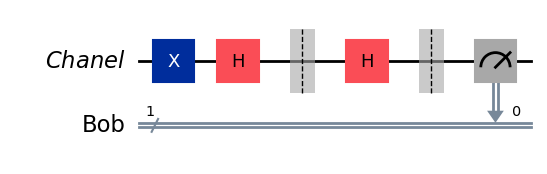

##############################
Results:
##############################
Number of sent bits: 1024
Number of lost bits by disagreement: 517
Number of lost bits by comparison: 50
Final sequence length: 457
Number of mismatches in the compared bits: 0
No eavesdropper detected.
Alice and Bob's sequences match.


In [ ]:
random.seed(SEED) # For reproducibility

nbits = 1024 # Total bits sent
print_one_circuit = True # For visualization

alice_bits = [random.choice([0, 1]) for _ in range(nbits)] # Create the initial bitsting
bob_bits = []

alice_used_h = []
bob_used_h = []


for bit in alice_bits:
    # Create quantum registers and circuit
    chanel = QuantumRegister(1, "Chanel")
    bob = ClassicalRegister(1, "Bob")
    qc = QuantumCircuit(chanel, bob)
    
    # Encode Alice's bit
    if bit:
        qc.x(chanel[0]) 
    
    # Alice randomly decides to apply H or not
    alice_h = random.choice([True, False])
    if alice_h:
        qc.h(chanel[0])
    qc.barrier()

    # Bob randomly decides to apply H or not
    bob_h = random.choice([True, False])
    if bob_h:
        qc.h(chanel[0])
    qc.barrier()
    
    # Measure and get Bob's bit
    qc.measure(chanel[0], bob[0])

    # Run the circuit
    job = sampler.run([qc], shots = 1)
    bob_bit = int(job.result()[0].data.Bob.get_bitstrings()[0])

    bob_bits.append(bob_bit)
    bob_used_h.append(bob_h)
    alice_used_h.append(alice_h)

    if print_one_circuit: 
        print(30 * "#")
        print("Circuit example:")
        print(30 * "#")
        print("Alice's bit:", bit)
        print("Alice used H:", alice_h)
        print("Bob used H:", bob_h)
        print("Bob's bit:", bob_bit)
        display(qc.draw("mpl"))
        print_one_circuit = False

# Indices where Alice and Bob used the same basis
agree = [i for i in range(nbits) if alice_used_h[i] == bob_used_h[i]] 

# Create the sequences
alice_sequence = [alice_bits[i] for i in agree]
bob_sequence = [bob_bits[i] for i in agree]

# Sample 10% of the bits to compare
len_sequence = len(agree)
n_shared_bits = int(0.1*len_sequence)
idx_sample = random.sample(range(len_sequence), n_shared_bits)

n_different_bits = 0
for idx in idx_sample:
    if alice_sequence[idx] != bob_sequence[idx]:
        n_different_bits+=1


print(30 * "#")
print("Results:")
print(30 * "#")
print("Number of sent bits:", nbits)
print("Number of lost bits by disagreement:", nbits - len_sequence)
print("Number of lost bits by comparison:", n_shared_bits)
print("Final sequence length:", len_sequence - n_shared_bits)
print("Number of mismatches in the compared bits:", n_different_bits)
if n_different_bits > 0:
    print("Eve is detected!")
else :
    print("No eavesdropper detected.")
if alice_sequence == bob_sequence:
    print("Alice and Bob's sequences match.")
else:
    print("Alice and Bob's sequences do not match.")


As expected, all shared bits match and so do the actual sequences. Notice that the final sequence length is 457, but Alice initially sent 1024 bits. This reduction is expected because Alice and Bob discard all bits for which they used different bases. In addition, they also discard the subset of bits that they publicly compare to check whether there has been any eavesdropping. Therefore, if we want to obtain a final secret key of a specific length, we need to send a larger number of initial bits.

Now let's see what happens if Eve tries to intercept Alice's qubits. Notice that if Eve chooses to measure in the Hadamard basis, she applies an H gate before the measurement and another H gate after the measurement. This allows her to resend the qubit in the same basis in which she measured it, trying to reduce the evidence of her eavesdropping.

##############################
Circuit example:
##############################
Alice's bit: 1
Alice used H: True
Eve used H: True
Eve's bit: 1
Bob used H: True
Bob's bit: 1


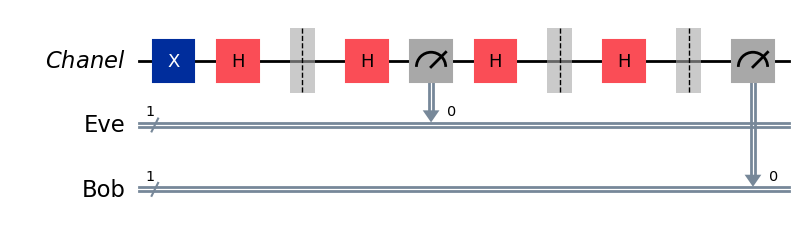

##############################
Results:
##############################
Number of sent bits: 1024
Number of lost bits by disagreement: 517
Number of lost bits by comparison: 50
Final sequence length: 457
Number of mismatches in the compared bits: 11
Eve is detected!
Alice and Bob's sequences do not match.


In [ ]:
random.seed(SEED) # For reproducibility

nbits = 1024 # Total bits sent
print_one_circuit = True # For visualization

alice_bits = [random.choice([0, 1]) for _ in range(nbits)] # Create the initial bitsting
bob_bits = []
eve_bits = []

alice_used_h = []
bob_used_h = []
eve_used_h = []


for bit in alice_bits:
    # Create quantum registers and circuit
    chanel = QuantumRegister(1, "Chanel")
    bob = ClassicalRegister(1, "Bob")
    eve = ClassicalRegister(1, "Eve")
    qc = QuantumCircuit(chanel, eve, bob)

    # Encode Alice's bit
    if bit:
        qc.x(chanel[0])
    
    # Alice randomly decides to apply H or not
    alice_h = random.choice([True, False])
    if alice_h:
        qc.h(chanel[0])
    qc.barrier()
    
    # Eve randomly decides to apply H or not (and measures)
    eve_h = random.choice([True, False])
    if eve_h:
        qc.h(chanel[0])
        qc.measure(chanel[0], eve[0])
        qc.h(chanel[0])
    else:
        qc.measure(chanel[0], eve[0])
    qc.barrier()

    # Bob randomly decides to apply H or not
    bob_h = random.choice([True, False])
    if bob_h:
        qc.h(chanel[0])
    qc.barrier()

    # Measure and get Bob's bit
    qc.measure(chanel[0], bob[0])

    # Run the circuit
    job = sampler.run([qc], shots = 1)
    bob_bit = int(job.result()[0].data.Bob.get_bitstrings()[0])
    eve_bit = int(job.result()[0].data.Eve.get_bitstrings()[0])

    bob_bits.append(bob_bit)
    eve_bits.append(eve_bit)
    bob_used_h.append(bob_h)
    alice_used_h.append(alice_h)
    eve_used_h.append(eve_h)

    if print_one_circuit: 
        print(30 * "#")
        print("Circuit example:")
        print(30 * "#")
        print("Alice's bit:", bit)
        print("Alice used H:", alice_h)
        print("Eve used H:", eve_h)
        print("Eve's bit:", eve_bit)
        print("Bob used H:", bob_h)
        print("Bob's bit:", bob_bit)
        display(qc.draw("mpl"))
        print_one_circuit = False
        
# Indices where Alice and Bob used the same basis
agree = [i for i in range(nbits) if alice_used_h[i] == bob_used_h[i]]

# Create the sequences
alice_sequence = [alice_bits[i] for i in agree]
bob_sequence = [bob_bits[i] for i in agree]
eve_sequence = [eve_bits[i] for i in agree]

# Sample 10% of the bits to compare
len_sequence = len(agree)
n_shared_bits = int(0.1*len_sequence)
idx_sample = random.sample(range(len_sequence), n_shared_bits)

n_different_bits = 0
for idx in idx_sample:
    if alice_sequence[idx] != bob_sequence[idx]:
        n_different_bits+=1


print(30 * "#")
print("Results:")
print(30 * "#")
print("Number of sent bits:", nbits)
print("Number of lost bits by disagreement:", nbits - len_sequence)
print("Number of lost bits by comparison:", n_shared_bits)
print("Final sequence length:", len_sequence - n_shared_bits)
print("Number of mismatches in the compared bits:", n_different_bits)
if n_different_bits > 0:
    print("Eve is detected!")
else :
    print("No eavesdropper detected.")
if alice_sequence == bob_sequence:
    print("Alice and Bob's sequences match.")
else:
    print("Alice and Bob's sequences do not match.")


When Eve is included in the communication, the results change significantly. In this case, 15 out of the 50 publicly compared bits are different. This is a clear indication that Eve has interfered with the transmission. Since Eve measures the qubits without knowing the correct basis, she can disturb their quantum states before they reach Bob. As a result, even when Alice and Bob later choose the same basis, some of Bob's measured bits may no longer match Alice's original bits. Therefore, Eve is detected and the protocol should not use the remaining sequence as a secret key. The fact that Alice and Bob's final sequences do not match confirms that the communication has been compromised.

In a real implementation, a single mismatch would not automatically be interpreted as evidence of eavesdropping. Some errors can naturally appear due to noise in the quantum channel, imperfect devices, or measurement inaccuracies. For this reason, practical quantum key distribution protocols do not rely on the presence of a single error, but on the overall error rate, usually measured through the Quantum Bit Error Rate (QBER). If this error rate remains below a certain threshold, the key may still be considered secure after applying the appropriate post-processing steps. If the threshold is exceeded, the protocol assumes that security cannot be guaranteed and the key must be discarded.

# E91 Protocol

In this section, we implement a basic simulation of the E91 quantum key distribution protocol. The goal is to show how Alice and Bob can generate a shared secret bitstring using entangled qubits instead of sending individually prepared qubits, as in BB84.

In this protocol, a pair of entangled qubits is first prepared in a Bell state. One qubit is given to Alice and the other one to Bob. Because the two qubits are entangled, their measurement results are strongly correlated when they measure in compatible bases. Alice and Bob then independently choose their measurement bases at random and measure their corresponding qubits.

After the measurements, Alice and Bob publicly compare which bases they used, but not the actual bit values. They only keep the bits corresponding to compatible measurement bases, since those are the ones expected to produce matching or correlated results. The remaining bits are discarded. Finally, they also share a subset of the bits to check for eavesdropping.

In this first implementation, no explicit eavesdropper is added to the circuit, so Alice and Bob are expected to obtain matching final sequences after keeping only the bits measured with compatible bases.

##############################
Circuit example:
##############################
Alice used H: False
Alice's bit: 1
Bob used H: True
Bob's bit: 0


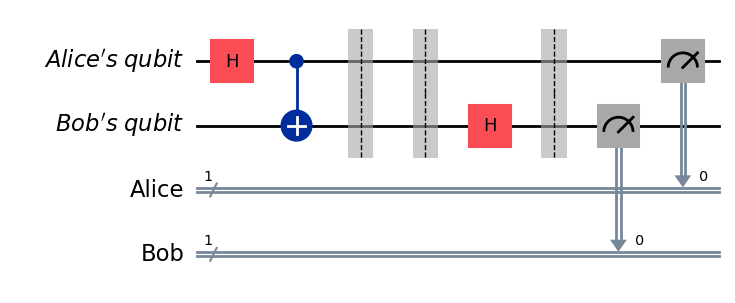

##############################
Results:
##############################
Number of measurements (total bits): 1024
Number of lost bits by disagreement: 505
Number of lost bits by comparison: 51
Final sequence length: 468
Number of mismatches in the compared bits: 0
No eavesdropper detected.
Alice and Bob's sequences match.


In [ ]:
random.seed(SEED) # For reproducibility

nbits = 1024 # Total bits sent
print_one_circuit = True # For visualization

alice_bits = []
bob_bits = []

alice_used_h = []
bob_used_h = []


for _ in range(nbits):
    # Create quantum registers and circuit
    alice_quantum = QuantumRegister(1, "Alice's qubit")
    bob_quantum = QuantumRegister(1, "Bob's qubit")
    alice_classical = ClassicalRegister(1, "Alice")
    bob_classical = ClassicalRegister(1, "Bob")
    qc = QuantumCircuit(alice_quantum, bob_quantum, alice_classical, bob_classical)

    # Create the Bell pair
    qc.h(alice_quantum[0])
    qc.cx(alice_quantum[0], bob_quantum[0])
    qc.barrier()

    # Alice randomly decides to apply H or not
    alice_h = random.choice([True, False])
    if alice_h:
        qc.h(alice_quantum[0])
    qc.barrier()

    # Bob randomly decides to apply H or not
    bob_h = random.choice([True, False])
    if bob_h:
        qc.h(bob_quantum[0])
    qc.barrier()

    # Measure and get both Alice's and Bob's bits
    qc.measure(bob_quantum[0], bob_classical[0])
    qc.measure(alice_quantum[0], alice_classical[0])

    # Run the circuit
    job = sampler.run([qc], shots = 1)
    bob_bit = int(job.result()[0].data.Bob.get_bitstrings()[0])
    alice_bit = int(job.result()[0].data.Alice.get_bitstrings()[0])

    bob_bits.append(bob_bit)
    alice_bits.append(alice_bit)
    bob_used_h.append(bob_h)
    alice_used_h.append(alice_h)

    if print_one_circuit: 
        print(30 * "#")
        print("Circuit example:")
        print(30 * "#")
        print("Alice used H:", alice_h)
        print("Alice's bit:", alice_bit)
        print("Bob used H:", bob_h)
        print("Bob's bit:", bob_bit)
        display(qc.draw("mpl"))
        print_one_circuit = False

# Indices where Alice and Bob used the same basis
agree = [i for i in range(nbits) if alice_used_h[i] == bob_used_h[i]]

# Create the sequences
alice_sequence = [alice_bits[i] for i in agree]
bob_sequence = [bob_bits[i] for i in agree]

# Sample 10% of the bits to compare
len_sequence = len(agree)
n_comparison_bits  = int(0.1*len_sequence)
idx_sample = random.sample(range(len_sequence), n_comparison_bits )

n_different_bits = 0
for idx in idx_sample:
    if alice_sequence[idx] != bob_sequence[idx]:
        n_different_bits+=1


print(30 * "#")
print("Results:")
print(30 * "#")
print("Number of measurements (total bits):", nbits)
print("Number of lost bits by disagreement:", nbits - len_sequence)
print("Number of lost bits by comparison:", n_comparison_bits )
print("Final sequence length:", len_sequence - n_comparison_bits )
print("Number of mismatches in the compared bits:", n_different_bits)
if n_different_bits > 0:
    print("Eve is detected!")
else :
    print("No eavesdropper detected.")
if alice_sequence == bob_sequence:
    print("Alice and Bob's sequences match.")
else:
    print("Alice and Bob's sequences do not match.")


As expected, Alice and Bob's final sequences match and no eavesdropper is detected. In this case, none of the compared bits are mismatched, so the expected correlations between Alice's and Bob's measurements are preserved. Therefore, the remaining unrevealed bits can be considered a valid shared secret key. As in BB84, if we want to obtain a final key of a specific length, we need to start with a larger number of initial measurements, since part of the data is discarded during basis comparison and eavesdropping detection.

Now let's see what happens if Eve tries to measure the entangled qubits.

##############################
Circuit example:
##############################
Eve used H: False
Eve's bit: 1
Alice used H: True
Alice's bit: 1
Bob used H: True
Bob's bit: 0


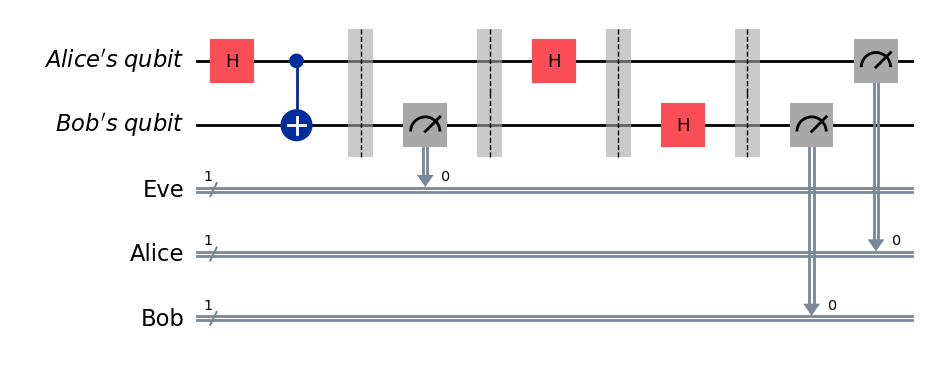

##############################
Results:
##############################
Number of measurements (total bits): 1024
Number of lost bits by disagreement: 511
Number of lost bits by comparison: 51
Final sequence length: 462
Number of mismatches in the compared bits: 29
Eve is detected!
Alice and Bob's sequences do not match.


In [ ]:
random.seed(SEED) # For reproducibility

nbits = 1024 # Total bits sent
print_one_circuit = True # For visualization

alice_bits = []
bob_bits = []
eve_bits = []

alice_used_h = []
bob_used_h = []


for _ in range(nbits):
    # Create quantum registers and circuit
    alice_quantum = QuantumRegister(1, "Alice's qubit")
    bob_quantum = QuantumRegister(1, "Bob's qubit")
    alice_classical = ClassicalRegister(1, "Alice")
    bob_classical = ClassicalRegister(1, "Bob")
    eve = ClassicalRegister(1, "Eve")
    qc = QuantumCircuit(alice_quantum, bob_quantum, eve, alice_classical, bob_classical)

    # Create the Bell pair
    qc.h(alice_quantum[0])
    qc.cx(alice_quantum[0], bob_quantum[0])
    qc.barrier()

    # Eve randomly decides to apply H or not (and measures)
    eve_h = random.choice([True, False])
    if eve_h:
        qc.h(bob_quantum[0])
        qc.measure(bob_quantum[0], eve[0])
        qc.h(bob_quantum[0])
    else:    
        qc.measure(bob_quantum[0], eve[0])

    qc.barrier()

    # Alice randomly decides to apply H or not
    alice_h = random.choice([True, False])
    if alice_h:
        qc.h(alice_quantum[0])
    qc.barrier()

    # Bob randomly decides to apply H or not
    bob_h = random.choice([True, False])
    if bob_h:
        qc.h(bob_quantum[0])
    qc.barrier()
    
    # Measure and get both Alice's and Bob's bits
    qc.measure(bob_quantum[0], bob_classical[0])
    qc.measure(alice_quantum[0], alice_classical[0])
    
    # Run the circuit
    job = sampler.run([qc], shots = 1)
    bob_bit = int(job.result()[0].data.Bob.get_bitstrings()[0])
    alice_bit = int(job.result()[0].data.Alice.get_bitstrings()[0])
    eve_bit = int(job.result()[0].data.Eve.get_bitstrings()[0])

    bob_bits.append(bob_bit)
    alice_bits.append(alice_bit)
    eve_bits.append(eve_bit)
    bob_used_h.append(bob_h)
    alice_used_h.append(alice_h)

    if print_one_circuit: 
        print(30 * "#")
        print("Circuit example:")
        print(30 * "#")
        print("Eve used H:", eve_h)
        print("Eve's bit:", eve_bit)
        print("Alice used H:", alice_h)
        print("Alice's bit:", alice_bit)
        print("Bob used H:", bob_h)
        print("Bob's bit:", bob_bit)
        display(qc.draw("mpl"))
        print_one_circuit = False

# Indices where Alice and Bob used the same basis
agree = [i for i in range(nbits) if alice_used_h[i] == bob_used_h[i]]

# Create the sequences
alice_sequence = [alice_bits[i] for i in agree]
bob_sequence = [bob_bits[i] for i in agree]

# Sample 10% of the bits to compare
len_sequence = len(agree)
n_comparison_bits  = int(0.1*len_sequence)
idx_sample = random.sample(range(len_sequence), n_comparison_bits )

n_different_bits = 0
for idx in idx_sample:
    if alice_sequence[idx] != bob_sequence[idx]:
        n_different_bits+=1


print(30 * "#")
print("Results:")
print(30 * "#")
print("Number of measurements (total bits):", nbits)
print("Number of lost bits by disagreement:", nbits - len_sequence)
print("Number of lost bits by comparison:", n_comparison_bits )
print("Final sequence length:", len_sequence - n_comparison_bits )
print("Number of mismatches in the compared bits:", n_different_bits)
if n_different_bits > 0:
    print("Eve is detected!")
else :
    print("No eavesdropper detected.")
if alice_sequence == bob_sequence:
    print("Alice and Bob's sequences match.")
else:
    print("Alice and Bob's sequences do not match.")


Again, Eve is detected and the remaining sequence should not be used as a secret key. In this case, the presence of Eve disturbs the expected correlations between Alice's and Bob's measurements. Since Eve measures Bob's qubit without knowing the correct basis, she can collapse the entangled state and modify the result that Bob later obtains. As a consequence, even when Alice and Bob use compatible bases, some of their measured bits no longer match. The mismatches found in the publicly compared subset indicate that the communication has been compromised.